# Healthcare Operations Exploratory Data Analysis

This notebook answers operational and financial business questions using discharge-weighted averages. Submitted charges are not revenue, and large charge/payment differences do not alone prove inefficiency.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.eda_analysis import load_clean_data, create_analysis_tables

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (11, 6), 'axes.titlesize': 14, 'axes.labelsize': 11})
df = load_clean_data(PROJECT_ROOT / 'data/processed/healthcare_operations_clean.csv')
tables = create_analysis_tables(df)
print(f'Loaded {len(df):,} hospital-DRG records.')

Loaded 145,879 hospital-DRG records.


## 1. Portfolio KPIs

In [2]:
kpis = tables['portfolio_kpis'].copy()
kpis['Formatted_Value'] = kpis.apply(lambda row: f"{row['Value']:,.0f}" if row['KPI'].startswith(('Number', 'Total_Discharges')) else f"${row['Value']:,.2f}", axis=1)
kpis[['KPI', 'Formatted_Value']]

,KPI,Formatted_Value
0,Number_of_Hospitals,"2,906"
1,Number_of_DRGs,540
2,Number_of_States_and_Territories,51
3,Total_Discharges,"4,952,481"
4,Weighted_Avg_Submitted_Charge,"$92,407.85"
5,Weighted_Avg_Total_Payment,"$18,359.99"
6,Weighted_Avg_Medicare_Payment,"$15,166.43"
7,Total_Estimated_Submitted_Charges,"$457,648,118,614.10"
8,Total_Estimated_Payments,"$90,927,479,550.00"
9,Total_Estimated_Medicare_Payments,"$75,111,479,229.00"


**Interpretation:** These KPIs establish the scale of the CMS dataset. Financial averages are weighted by discharges, so high-volume services influence the result in proportion to the number of discharges. Estimated totals are analytical estimates, not reported hospital revenue.

## 2. Highest-volume hospitals

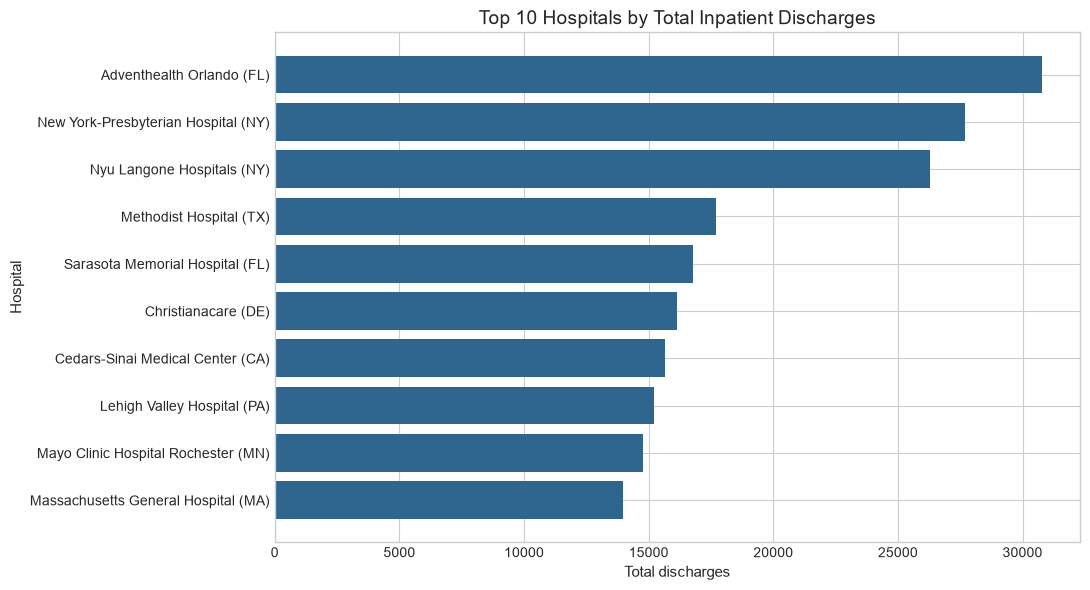

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,Total_Discharges
1300,220071,Massachusetts General Hospital,MA,13982
1417,240010,Mayo Clinic Hospital Rochester,MN,14778
2201,390133,Lehigh Valley Hospital,PA,15219
393,050625,Cedars-Sinai Medical Center,CA,15641
522,080001,Christianacare,DE,16137
583,100087,Sarasota Memorial Hospital,FL,16770
2504,450388,Methodist Hospital,TX,17711
1804,330214,Nyu Langone Hospitals,NY,26286
1758,330101,New York-Presbyterian Hospital,NY,27689
537,100007,Adventhealth Orlando,FL,30767


In [3]:
top_hospitals = tables['hospital_summary'].head(10).sort_values('Total_Discharges')
labels = top_hospitals['Rndrng_Prvdr_Org_Name'] + ' (' + top_hospitals['Rndrng_Prvdr_State_Abrvtn'] + ')'
ax = plt.gca()
ax.barh(labels, top_hospitals['Total_Discharges'], color='#2F6690')
ax.set(title='Top 10 Hospitals by Total Inpatient Discharges', xlabel='Total discharges', ylabel='Hospital')
plt.tight_layout(); plt.show()
top_hospitals[['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn', 'Total_Discharges']]

**Interpretation:** These providers manage the largest inpatient volumes in this dataset and may be priority candidates for capacity-planning analysis. Volume alone does not describe care quality or efficiency.

## 3. Highest-volume DRGs

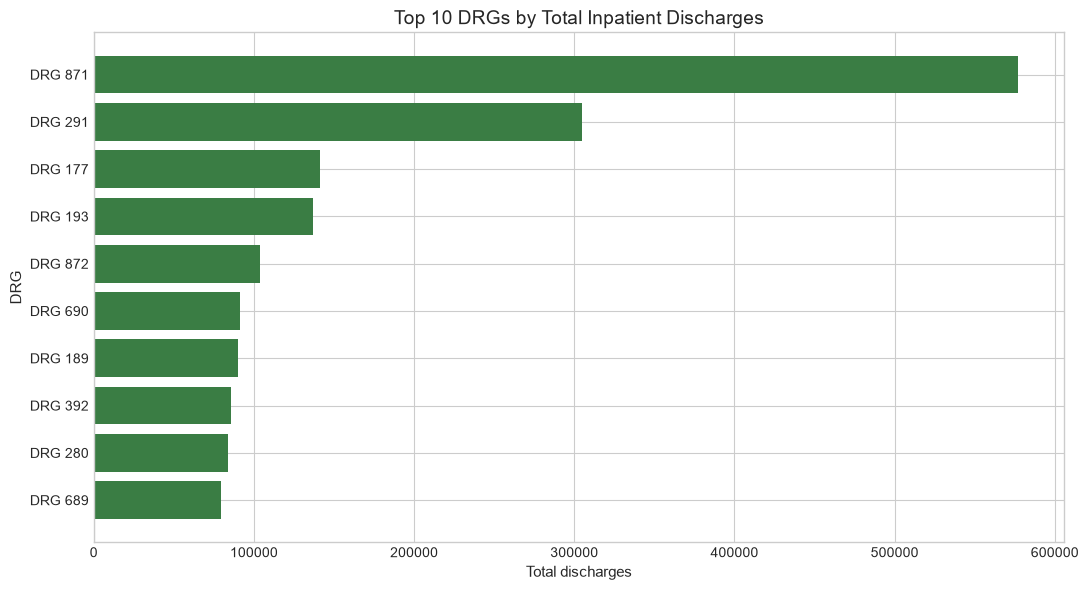

,DRG_Cd,DRG_Desc,Total_Discharges
420,689,KIDNEY AND URINARY TRACT INFECTIONS WITH MCC,79740
171,280,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE ...",83841
243,392,"ESOPHAGITIS, GASTROENTERITIS AND MISCELLANEOUS...",85970
111,189,PULMONARY EDEMA AND RESPIRATORY FAILURE,89991
421,690,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,91493
489,872,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,103998
115,193,SIMPLE PNEUMONIA AND PLEURISY WITH MCC,136649
101,177,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,141351
177,291,HEART FAILURE AND SHOCK WITH MCC,304694
488,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,577119


In [4]:
top_drgs = tables['drg_summary'].head(10).sort_values('Total_Discharges')
labels = 'DRG ' + top_drgs['DRG_Cd'].astype(str)
plt.barh(labels, top_drgs['Total_Discharges'], color='#3A7D44')
plt.title('Top 10 DRGs by Total Inpatient Discharges'); plt.xlabel('Total discharges'); plt.ylabel('DRG')
plt.tight_layout(); plt.show()
top_drgs[['DRG_Cd', 'DRG_Desc', 'Total_Discharges']]

**Interpretation:** High-volume DRGs identify services consuming the most aggregate inpatient capacity. DRG 871 is the leading volume category, making sepsis-related operations an important area for deeper resource planning.

## 4. State-level discharge volume

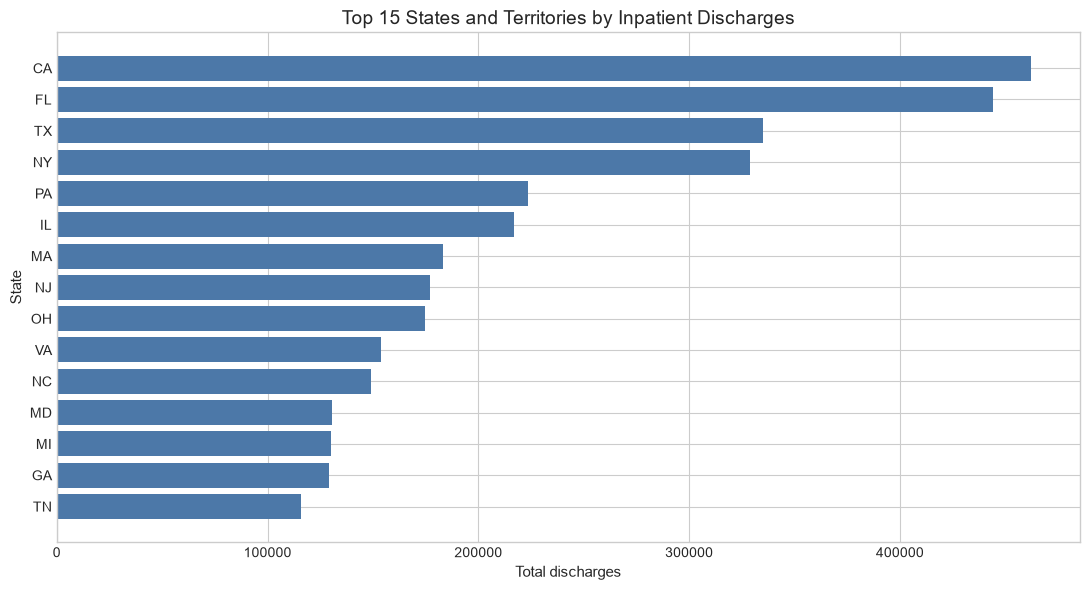

In [5]:
top_states = tables['state_summary'].head(15).sort_values('Total_Discharges')
plt.barh(top_states['Rndrng_Prvdr_State_Abrvtn'], top_states['Total_Discharges'], color='#4C78A8')
plt.title('Top 15 States and Territories by Inpatient Discharges'); plt.xlabel('Total discharges'); plt.ylabel('State')
plt.tight_layout(); plt.show()

**Interpretation:** California, Florida, Texas, and New York account for the largest discharge totals. Population, provider participation, demographics, and service mix may all contribute, so volume should not be interpreted as utilization rate without a population denominator.

## 5. Most expensive high-volume DRGs

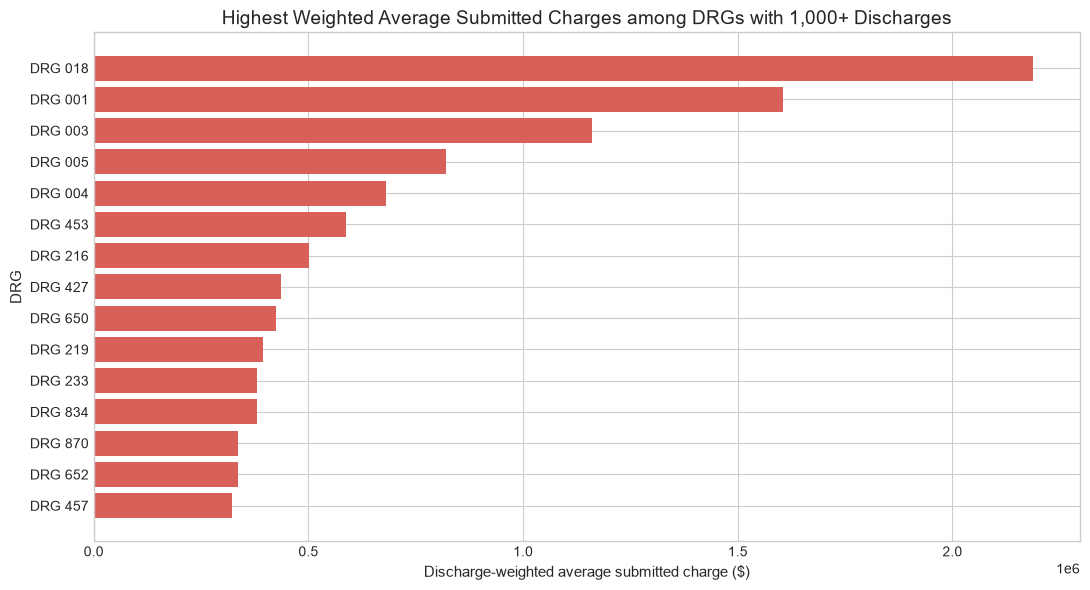

,DRG_Cd,DRG_Desc,Total_Discharges,Weighted_Avg_Submtd_Cvrd_Chrg
11,018,CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTH...,1360,2.187781e+06
0,001,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,1814,1.604490e+06
1,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,6749,1.160394e+06
3,005,LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSP...,1043,8.199992e+05
2,004,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,3589,6.804750e+05
278,453,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,1012,5.886266e+05
131,216,CARDIAC VALVE AND OTHER MAJOR CARDIOTHORACIC P...,2577,5.010840e+05
261,427,MULTIPLE LEVEL COMBINED ANTERIOR AND POSTERIOR...,1170,4.359698e+05
397,650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,2130,4.253306e+05
133,219,CARDIAC VALVE AND OTHER MAJOR CARDIOTHORACIC P...,12333,3.933016e+05


In [6]:
expensive_drgs = tables['expensive_high_volume_drgs'].head(15).sort_values('Weighted_Avg_Submtd_Cvrd_Chrg')
plt.barh('DRG ' + expensive_drgs['DRG_Cd'].astype(str), expensive_drgs['Weighted_Avg_Submtd_Cvrd_Chrg'], color='#D95F59')
plt.title('Highest Weighted Average Submitted Charges among DRGs with 1,000+ Discharges')
plt.xlabel('Discharge-weighted average submitted charge ($)'); plt.ylabel('DRG')
plt.tight_layout(); plt.show()
expensive_drgs[['DRG_Cd', 'DRG_Desc', 'Total_Discharges', 'Weighted_Avg_Submtd_Cvrd_Chrg']].sort_values('Weighted_Avg_Submtd_Cvrd_Chrg', ascending=False)

**Interpretation:** The 1,000-discharge threshold reduces the chance of highlighting unstable low-volume averages. Complex therapies and transplants lead submitted charges, but submitted charges are not actual revenue or cost.

## 6. Rural versus urban comparison

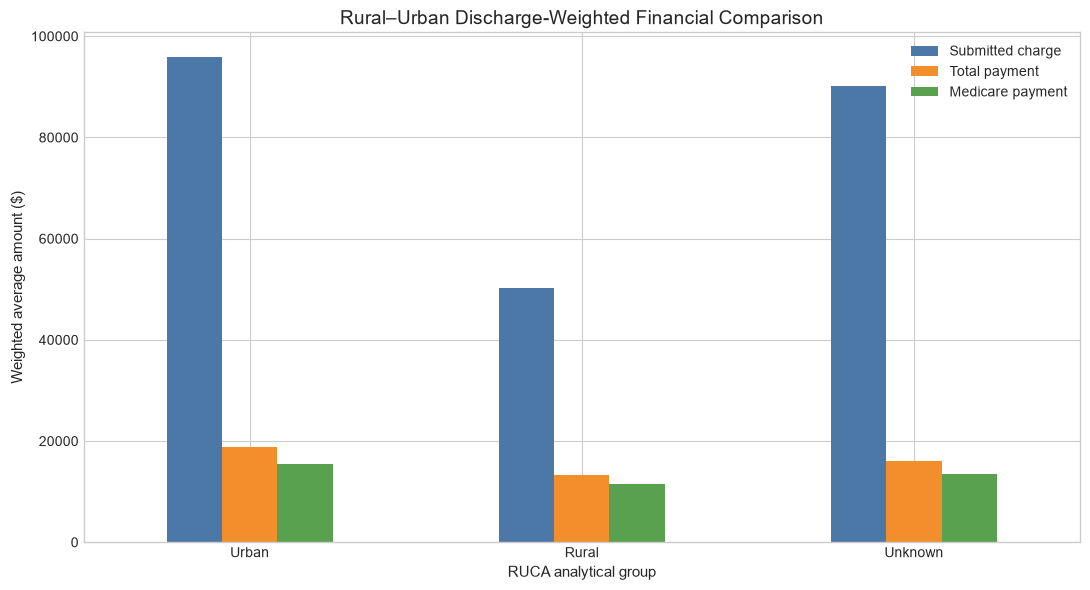

,Rural_Urban_Group,Total_Discharges,Service_Record_Count,Total_Estimated_Submitted_Charges,Total_Estimated_Total_Payments,Total_Estimated_Medicare_Payments,Weighted_Avg_Submtd_Cvrd_Chrg,Weighted_Avg_Tot_Pymt_Amt,Weighted_Avg_Mdcr_Pymt_Amt,Weighted_Payment_Gap,Weighted_Medicare_Payment_Gap,Weighted_Total_Payment_Coverage_Pct,Weighted_Medicare_Coverage_Pct,Weighted_Charge_to_Total_Payment_Ratio
0,Urban,4552373,131744,4.367609e+11,8.556632e+10,7.049044e+10,95941.359972,18795.980764,15484.328040,77145.379208,80457.031932,25.144154,20.495514,5.245593
1,Rural,380557,13557,1.912404e+10,5.046012e+09,4.355975e+09,50252.751945,13259.542862,11446.313798,36993.209083,38806.438147,32.087696,27.373287,3.874337
2,Unknown,19551,578,1.763225e+09,3.151524e+08,2.650675e+08,90185.943072,16119.500793,13557.746202,74066.442279,76628.196870,20.512726,16.842276,5.643338


In [7]:
ru = tables['rural_urban_summary'].set_index('Rural_Urban_Group')
ru[['Weighted_Avg_Submtd_Cvrd_Chrg', 'Weighted_Avg_Tot_Pymt_Amt', 'Weighted_Avg_Mdcr_Pymt_Amt']].plot.bar(color=['#4C78A8', '#F28E2B', '#59A14F'])
plt.title('Rural–Urban Discharge-Weighted Financial Comparison'); plt.xlabel('RUCA analytical group'); plt.ylabel('Weighted average amount ($)')
plt.xticks(rotation=0); plt.legend(['Submitted charge', 'Total payment', 'Medicare payment']); plt.tight_layout(); plt.show()
ru.reset_index()

**Interpretation:** Urban records have higher weighted submitted charges and payments, while rural records show higher weighted coverage percentages. These differences may reflect case mix, regional prices, hospital characteristics, or service availability; they do not alone establish better performance. RUCA 1–3 are grouped as Urban and 4–10 as Rural.

## 7. Hospitals and DRGs with the largest weighted payment gaps

In [8]:
hospital_gaps = tables['hospital_summary'].nlargest(10, 'Weighted_Payment_Gap')
drg_gaps = tables['drg_summary'].query('Total_Discharges >= 1000').nlargest(10, 'Weighted_Payment_Gap')
display(hospital_gaps[['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Total_Discharges', 'Weighted_Payment_Gap']])
display(drg_gaps[['DRG_Cd', 'DRG_Desc', 'Total_Discharges', 'Weighted_Payment_Gap']])

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Total_Discharges,Weighted_Payment_Gap
926,140310,"Rush Specialty Hospital, Llc",14,521173.214283
460,060014,Hca Healthone Presbyterian St Lukes,596,505715.278523
996,150166,Pinnacle Hospital,109,452596.486238
2548,450659,Hca Houston Healthcare Medical Center,410,446752.200001
1689,310092,Capital Health Regional Medical Center,1109,443930.339945
345,050441,Stanford Health Care,11829,373029.074816
393,050625,Cedars-Sinai Medical Center,15641,360328.742536
350,050464,Doctors Medical Center,2691,349818.080269
1667,310044,Capital Health Medical Center - Hopewell,1447,344058.890118
2718,490147,Inova Specialty Hospital,11,328800.999999


,DRG_Cd,DRG_Desc,Total_Discharges,Weighted_Payment_Gap
11,018,CHIMERIC ANTIGEN RECEPTOR (CAR) T-CELL AND OTH...,1360,1.727635e+06
0,001,HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SY...,1814,1.254897e+06
1,003,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,6749,9.142160e+05
3,005,LIVER TRANSPLANT WITH MCC OR INTESTINAL TRANSP...,1043,6.642687e+05
2,004,TRACHEOSTOMY WITH MV >96 HOURS OR PRINCIPAL DI...,3589,5.413564e+05
278,453,COMBINED ANTERIOR AND POSTERIOR SPINAL FUSION ...,1012,4.833734e+05
131,216,CARDIAC VALVE AND OTHER MAJOR CARDIOTHORACIC P...,2577,3.934500e+05
397,650,KIDNEY TRANSPLANT WITH HEMODIALYSIS WITH MCC,2130,3.664883e+05
261,427,MULTIPLE LEVEL COMBINED ANTERIOR AND POSTERIOR...,1170,3.597693e+05
139,233,CORONARY BYPASS WITH CARDIAC CATHETERIZATION O...,6594,3.110683e+05


**Interpretation:** These groups show larger differences between submitted charges and total payments and may warrant further investigation. The gap may reflect treatment complexity, market conditions, patient mix, or pricing practices; it does not alone prove inefficiency.

## 8. State weighted charges and payments

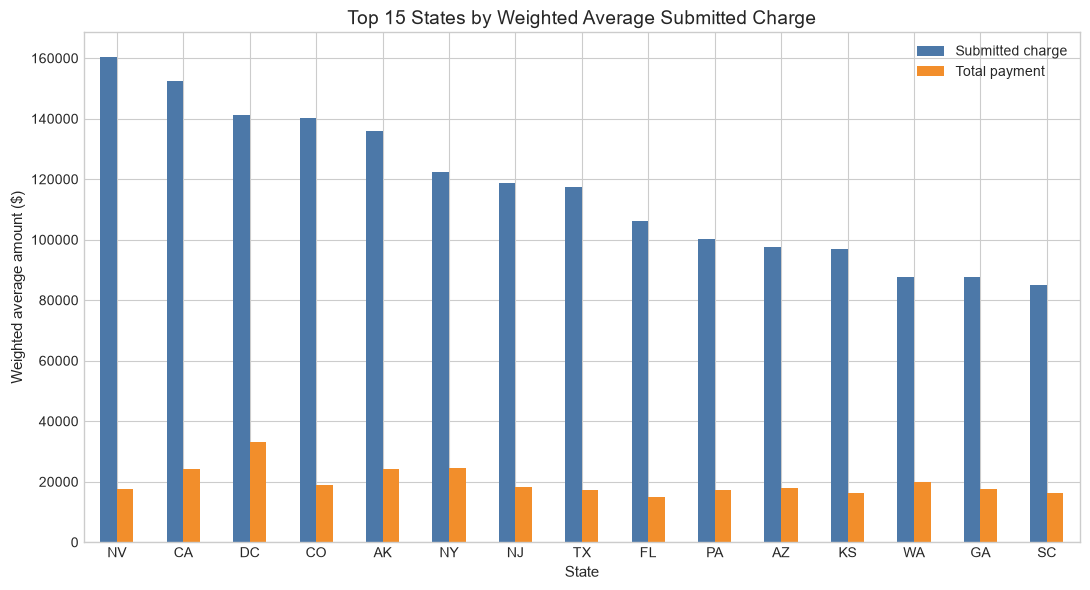

In [9]:
states = tables['state_summary'].sort_values('Weighted_Avg_Submtd_Cvrd_Chrg', ascending=False).head(15)
states.set_index('Rndrng_Prvdr_State_Abrvtn')[['Weighted_Avg_Submtd_Cvrd_Chrg', 'Weighted_Avg_Tot_Pymt_Amt']].plot.bar(color=['#4C78A8', '#F28E2B'])
plt.title('Top 15 States by Weighted Average Submitted Charge'); plt.xlabel('State'); plt.ylabel('Weighted average amount ($)')
plt.legend(['Submitted charge', 'Total payment']); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Interpretation:** State variation may reflect local price levels, case mix, market structure, and provider mix. This comparison flags geographic differences for investigation rather than attributing causality.

## 9. Coverage percentage distributions

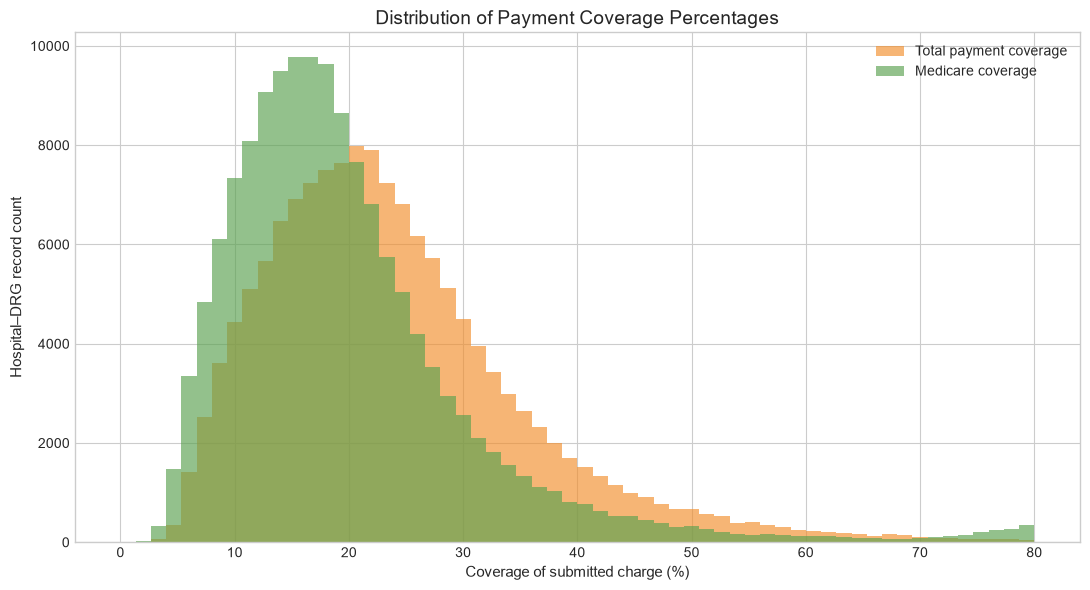

,Metric,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,Total_Payment_Coverage_Pct,145879.0,25.778937,16.328432,2.871990,6.411624,9.117970,15.989751,22.346196,30.383842,53.878938,90.720442,653.652873
1,Medicare_Coverage_Pct,145879.0,20.960908,14.504423,1.889145,5.120612,7.305733,12.743835,17.777482,24.314618,45.096711,82.937276,636.459774


In [10]:
df[['Total_Payment_Coverage_Pct', 'Medicare_Coverage_Pct']].plot.hist(bins=60, alpha=0.65, range=(0, 80), color=['#F28E2B', '#59A14F'])
plt.title('Distribution of Payment Coverage Percentages'); plt.xlabel('Coverage of submitted charge (%)'); plt.ylabel('Hospital–DRG record count')
plt.legend(['Total payment coverage', 'Medicare coverage']); plt.tight_layout(); plt.show()
tables['coverage_percentage_distribution']

**Interpretation:** The distributions show how much of submitted charges is represented by average payments. Coverage percentages compare different financial concepts and should not be treated as collection rates.

## 10. Charge-to-payment ratio outliers

In [11]:
q1 = df['Charge_to_Total_Payment_Ratio'].quantile(.25); q3 = df['Charge_to_Total_Payment_Ratio'].quantile(.75)
upper_fence = q3 + 1.5 * (q3 - q1)
print(f'IQR upper fence: {upper_fence:.2f}; records above fence: {len(tables["charge_to_payment_ratio_outliers"]):,}')
tables['charge_to_payment_ratio_outliers'][['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'DRG_Cd', 'Tot_Dschrgs', 'Charge_to_Total_Payment_Ratio']].head(20)

IQR upper fence: 10.70; records above fence: 7,998


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,DRG_Cd,Tot_Dschrgs,Charge_to_Total_Payment_Ratio
81459,290054,Centennial Hills Hospital Medical Center,699,18,34.819064
86675,310092,Capital Health Regional Medical Center,189,19,34.066874
84845,310044,Capital Health Medical Center - Hopewell,189,32,33.666651
84884,310044,Capital Health Medical Center - Hopewell,812,16,32.883787
84841,310044,Capital Health Medical Center - Hopewell,065,12,32.852762
84857,310044,Capital Health Medical Center - Hopewell,312,27,31.812122
84887,310044,Capital Health Medical Center - Hopewell,872,27,31.351762
84865,310044,Capital Health Medical Center - Hopewell,378,30,31.183116
58540,190176,East Jefferson General Hospital,652,15,30.192287
84883,310044,Capital Health Medical Center - Hopewell,699,16,29.883377


**Interpretation:** The IQR rule identifies unusual ratios statistically, not operationally. These records may warrant review, but high ratios can arise from multiple legitimate clinical and market factors.

## 11. High-volume and high-cost hospital–DRG combinations

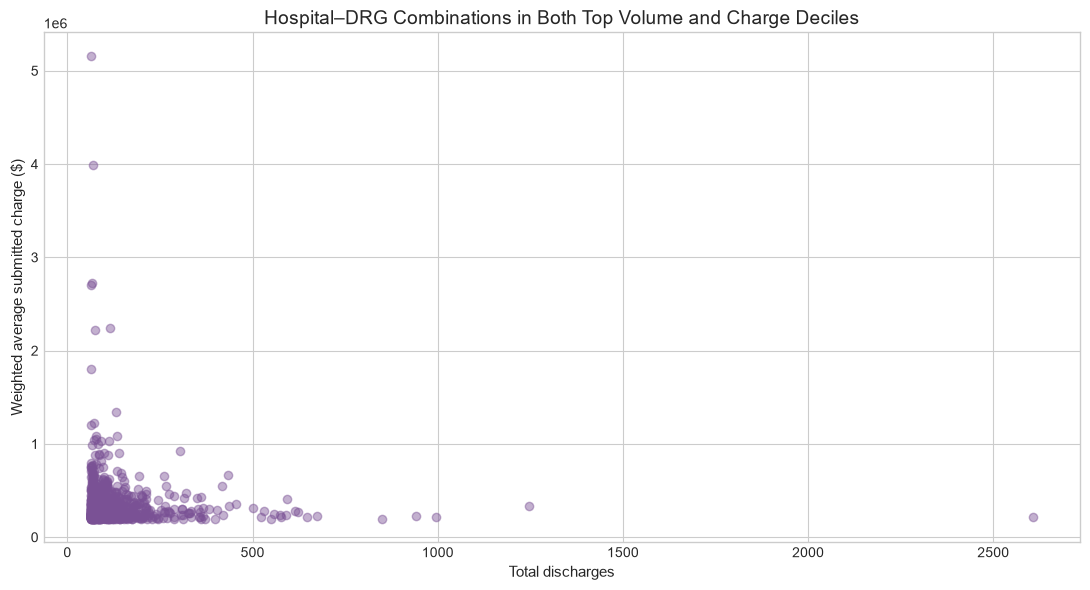

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,DRG_Cd,DRG_Desc,Total_Discharges,Weighted_Avg_Submtd_Cvrd_Chrg
90364,330101,New York-Presbyterian Hospital,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,2607,218019.01534
19399,050625,Cedars-Sinai Medical Center,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,1247,330923.55333
89839,330059,Montefiore Medical Center,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,995,212309.93065
93648,330214,Nyu Langone Hospitals,470,MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTA...,940,224069.04149
54155,170123,Wesley Medical Center,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,850,197966.65647
132170,450775,Hca Houston Healthcare Kingwood,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,674,228559.72997
80989,290039,Mountainview Hospital,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,646,213503.05573
18105,050549,Los Robles Hospital & Medical Center,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,623,273363.87159
7726,050022,Riverside Community Hospital,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,614,276017.47068
16569,050441,Stanford Health Care,871,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,594,413501.09596


In [12]:
priority = tables['high_volume_high_cost_combinations']
plt.scatter(priority['Total_Discharges'], priority['Weighted_Avg_Submtd_Cvrd_Chrg'], alpha=.45, color='#7A5195')
plt.title('Hospital–DRG Combinations in Both Top Volume and Charge Deciles'); plt.xlabel('Total discharges'); plt.ylabel('Weighted average submitted charge ($)')
plt.tight_layout(); plt.show()
priority[['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'DRG_Cd', 'DRG_Desc', 'Total_Discharges', 'Weighted_Avg_Submtd_Cvrd_Chrg']].head(20)

**Interpretation:** These combinations sit in the top decile for both volume and submitted charge and can help prioritize capacity, contracting, and service-line reviews. The thresholds are screening rules, not proof of poor performance.

## 12. Transparent hospital benchmarking scorecard

In [13]:
scorecard = tables['hospital_summary'].copy()
scorecard['Volume_Percentile'] = scorecard['Total_Discharges'].rank(pct=True) * 100
scorecard['Coverage_Percentile'] = scorecard['Weighted_Total_Payment_Coverage_Pct'].rank(pct=True) * 100
scorecard['Lower_Ratio_Percentile'] = (1 - scorecard['Weighted_Charge_to_Total_Payment_Ratio'].rank(pct=True)) * 100
scorecard['Service_Diversity_Percentile'] = scorecard['Service_Record_Count'].rank(pct=True) * 100
scorecard['Hospital_Operational_Benchmark_Score'] = (
    .35 * scorecard['Volume_Percentile'] + .30 * scorecard['Coverage_Percentile'] +
    .20 * scorecard['Lower_Ratio_Percentile'] + .15 * scorecard['Service_Diversity_Percentile']
)
scorecard.sort_values('Hospital_Operational_Benchmark_Score', ascending=False)[['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn', 'Volume_Percentile', 'Coverage_Percentile', 'Lower_Ratio_Percentile', 'Service_Diversity_Percentile', 'Hospital_Operational_Benchmark_Score']].head(20)

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,Volume_Percentile,Coverage_Percentile,Lower_Ratio_Percentile,Service_Diversity_Percentile,Hospital_Operational_Benchmark_Score
1245,210023,"Luminis Health Anne Arundel Medical Center, Inc",MD,98.313833,98.795595,99.036476,96.524432,98.334480
1236,210009,"Johns Hopkins Hospital, The",MD,98.279422,97.487956,97.866483,99.225740,98.101342
1229,210001,Meritus Medical Center,MD,93.289745,98.657949,98.933242,90.674467,95.636614
1230,210002,University Of Maryland Medical Center,MD,91.225052,98.623538,98.864418,94.993118,95.537681
1239,210015,Medstar Franklin Square Medical Center,MD,93.771507,97.969718,98.279422,91.018582,95.519615
1304,220077,Baystate Medical Center,MA,99.139711,91.569167,91.569167,98.847213,95.310564
1244,210022,Suburban Hospital,MD,92.704749,97.900895,98.210599,92.171370,95.284756
1233,210005,Frederick Health Hospital,MD,92.945630,98.348245,98.589126,90.141087,95.274432
1243,210019,"Tidalhealth Peninsula Regional, Inc",MD,92.326222,98.072953,98.348245,90.433586,94.970750
1262,210049,University Of Md Upper Chesapeake Medical Center,MD,92.429456,98.279422,98.520303,88.162423,94.762560


**Formula and limitations:** Volume receives 35%, payment coverage 30%, lower charge-to-payment ratio 20%, and service diversity 15%. Higher component percentiles increase the score. This is a transparent benchmarking aid—not an efficiency, quality, profitability, or causal score—and results depend on the chosen weights and available CMS measures.